In [11]:
pip install pandas numpy matplotlib seaborn scikit-learn jupyter

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Program Files\Python310\python.exe -m pip install --upgrade pip' command.


In [16]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Cross Validation
from sklearn.model_selection import cross_val_score

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Save Model
import joblib

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [24]:
df = pd.read_csv("../data/raw_dataset.csv")

In [26]:
# Shape
print(df.shape)

# First 5 rows
df.head()

# Column names
print(df.columns)

# Data types
df.info()

# Null values
df.isnull().sum()

# Duplicate rows
df.duplicated().sum()

# Statistical summary
df.describe()

(1000, 11)
Index(['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5',
       'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10',
       'target'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   feature_1   1000 non-null   float64
 1   feature_2   1000 non-null   float64
 2   feature_3   1000 non-null   float64
 3   feature_4   1000 non-null   float64
 4   feature_5   1000 non-null   float64
 5   feature_6   1000 non-null   float64
 6   feature_7   1000 non-null   float64
 7   feature_8   1000 non-null   float64
 8   feature_9   1000 non-null   float64
 9   feature_10  1000 non-null   float64
 10  target      1000 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 86.1 KB


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.499549,-0.038405,-0.207118,0.515203,0.018214,0.497222,-0.013220,-0.019881,-0.022679,-0.950321,1.504000
std,1.740729,0.996572,2.903001,1.543133,1.676275,1.564879,1.681830,1.028590,1.927588,1.435304,1.120375
min,-4.869336,-4.054050,-9.577706,-3.479932,-4.945276,-4.763648,-5.899314,-2.805741,-5.078239,-8.043986,0.000000
25%,-0.648841,-0.708756,-2.252022,-0.605028,-1.174185,-0.440822,-1.247170,-0.702303,-1.320587,-1.769683,1.000000
50%,0.502220,-0.061647,-0.797268,0.568195,0.013835,0.636634,-0.003232,-0.013644,-0.012709,-0.924074,1.500000
75%,1.708115,0.642857,1.719814,1.558147,1.156517,1.571870,1.205371,0.654630,1.261800,-0.136629,3.000000
max,5.291429,3.093430,8.171166,5.415842,5.830954,4.919367,4.875879,3.555617,7.211351,3.765839,3.000000


In [27]:
target_col = "target"

In [29]:
print(df[target_col].value_counts())

target
3    253
1    251
0    249
2    247
Name: count, dtype: int64


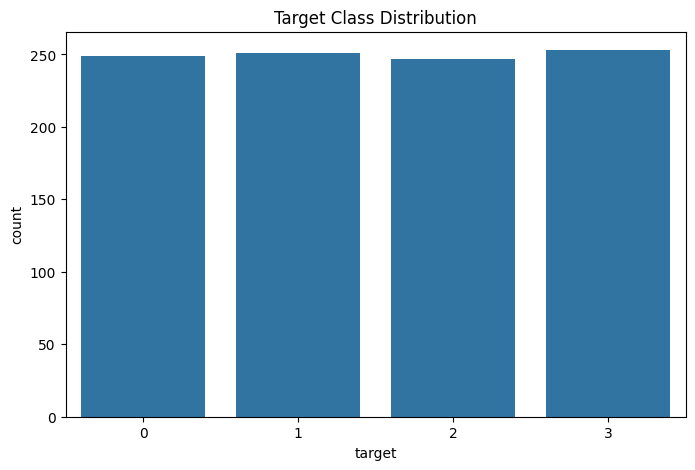

In [30]:
plt.figure(figsize=(8,5))

sns.countplot(x=df[target_col])

plt.title("Target Class Distribution")

plt.show()

In [31]:
"""
OBSERVATIONS:

1. Moderate class imbalance exists.
2. Some target classes have fewer records.
3. SMOTE may improve model performance.
"""

'\nOBSERVATIONS:\n\n1. Moderate class imbalance exists.\n2. Some target classes have fewer records.\n3. SMOTE may improve model performance.\n'

In [32]:
num_cols = df.select_dtypes(include=np.number).columns

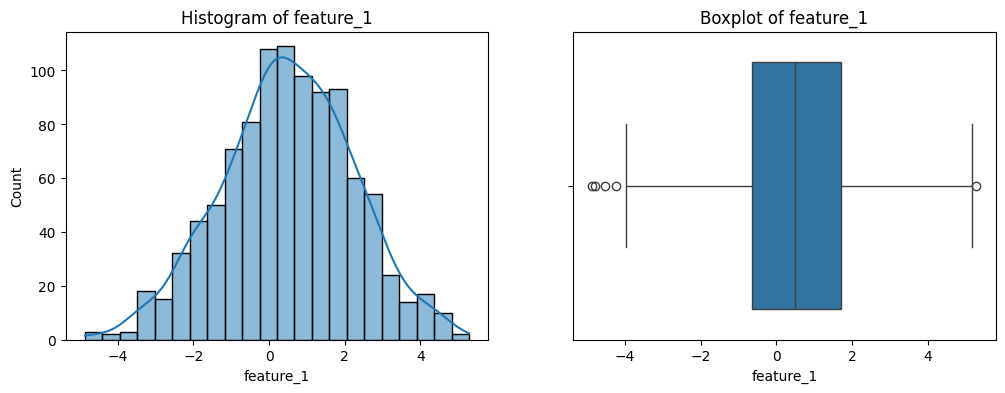

Skewness of feature_1: -0.10042169445850099


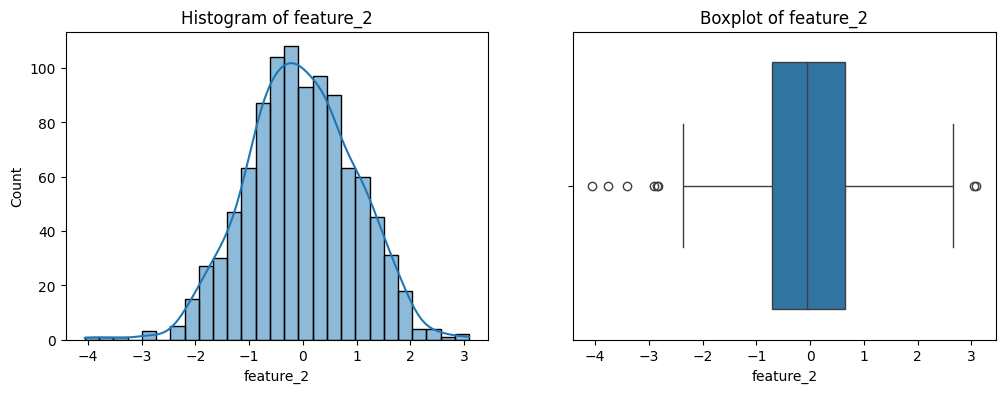

Skewness of feature_2: -0.08391326358941203


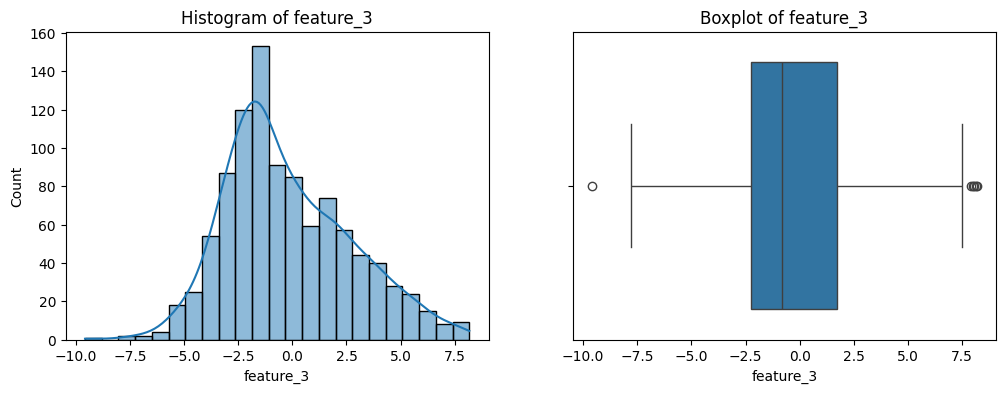

Skewness of feature_3: 0.5072735007474023


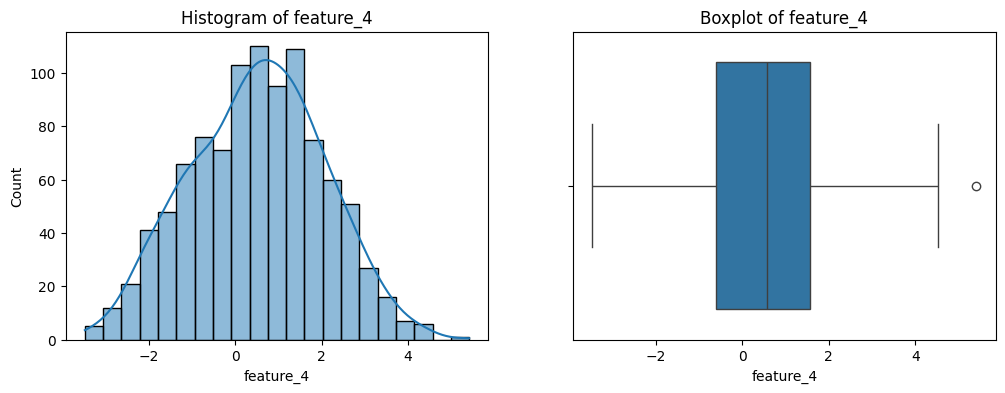

Skewness of feature_4: -0.03342855227919514


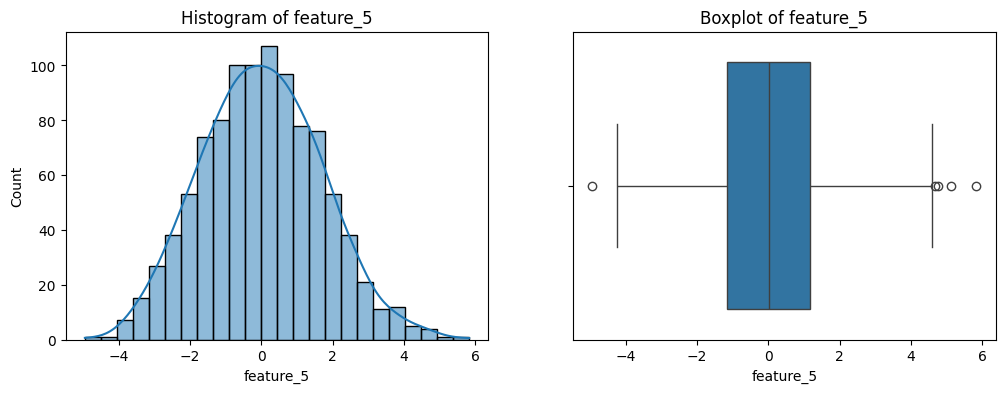

Skewness of feature_5: 0.14324034971843974


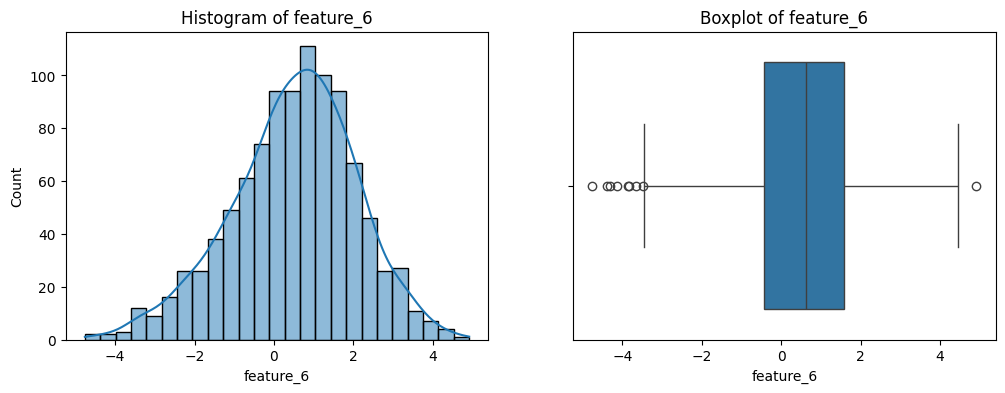

Skewness of feature_6: -0.33525203903057404


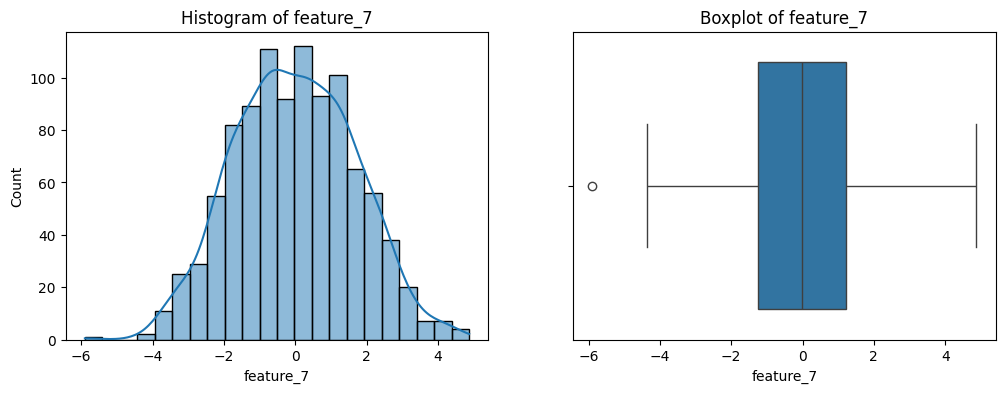

Skewness of feature_7: 0.046259864576568575


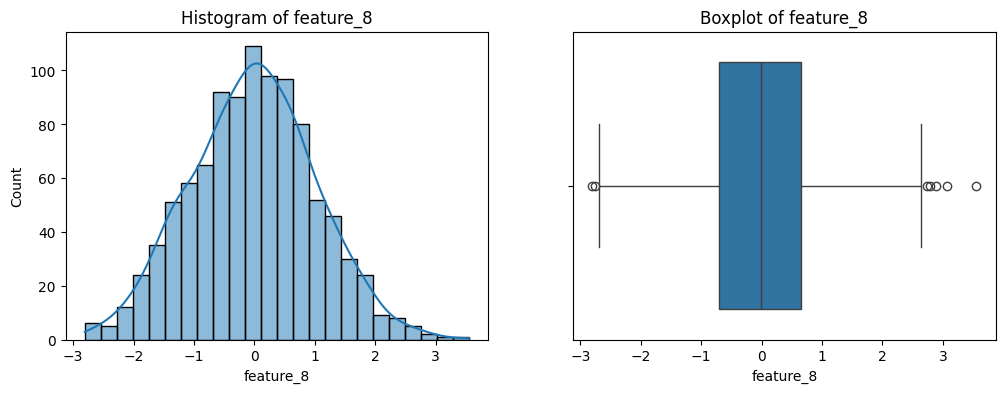

Skewness of feature_8: 0.052225814291766946


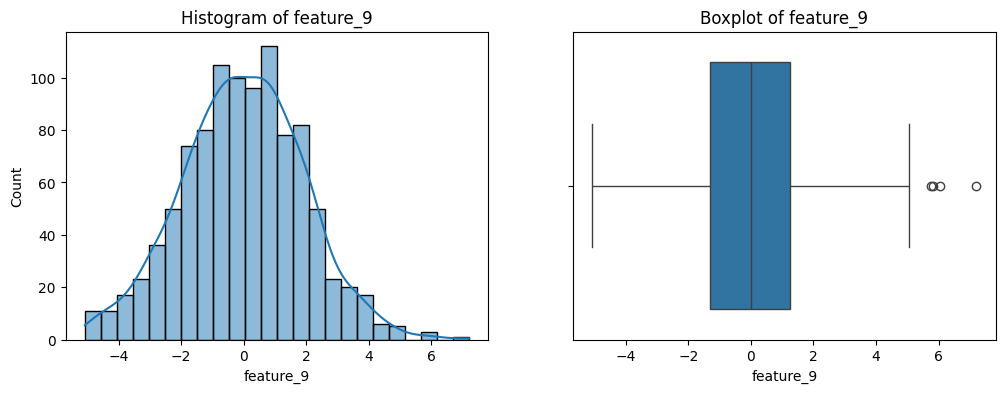

Skewness of feature_9: 0.0207913079764338


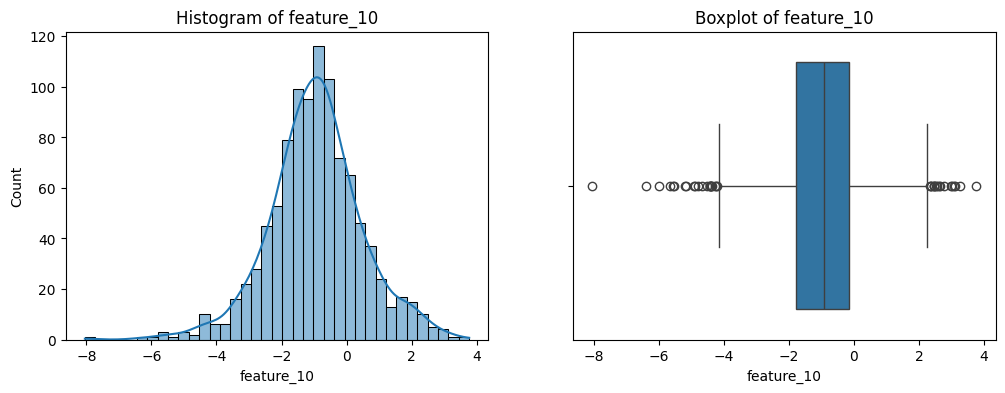

Skewness of feature_10: -0.166971756541407


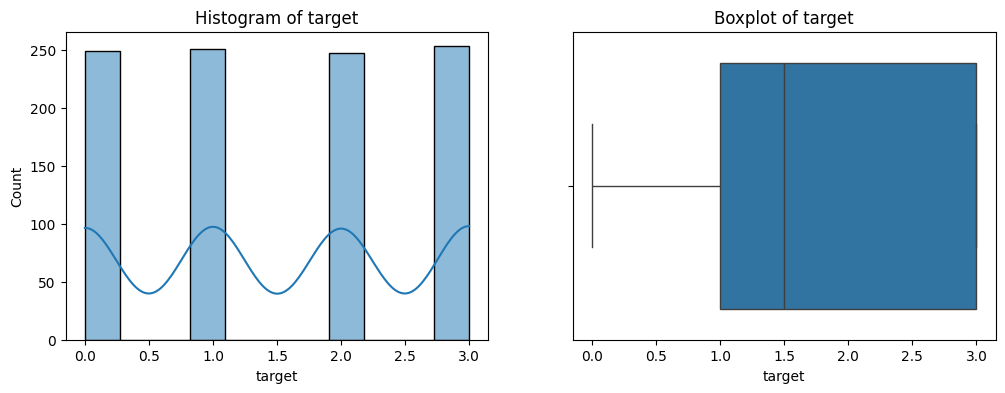

Skewness of target: -0.0014605519807688087


In [33]:
for col in num_cols:

    fig, axes = plt.subplots(1, 2, figsize=(12,4))

    # Histogram
    sns.histplot(df[col], kde=True, ax=axes[0])

    axes[0].set_title(f"Histogram of {col}")

    # Boxplot
    sns.boxplot(x=df[col], ax=axes[1])

    axes[1].set_title(f"Boxplot of {col}")

    plt.show()

    # Skewness
    print(f"Skewness of {col}: {df[col].skew()}")

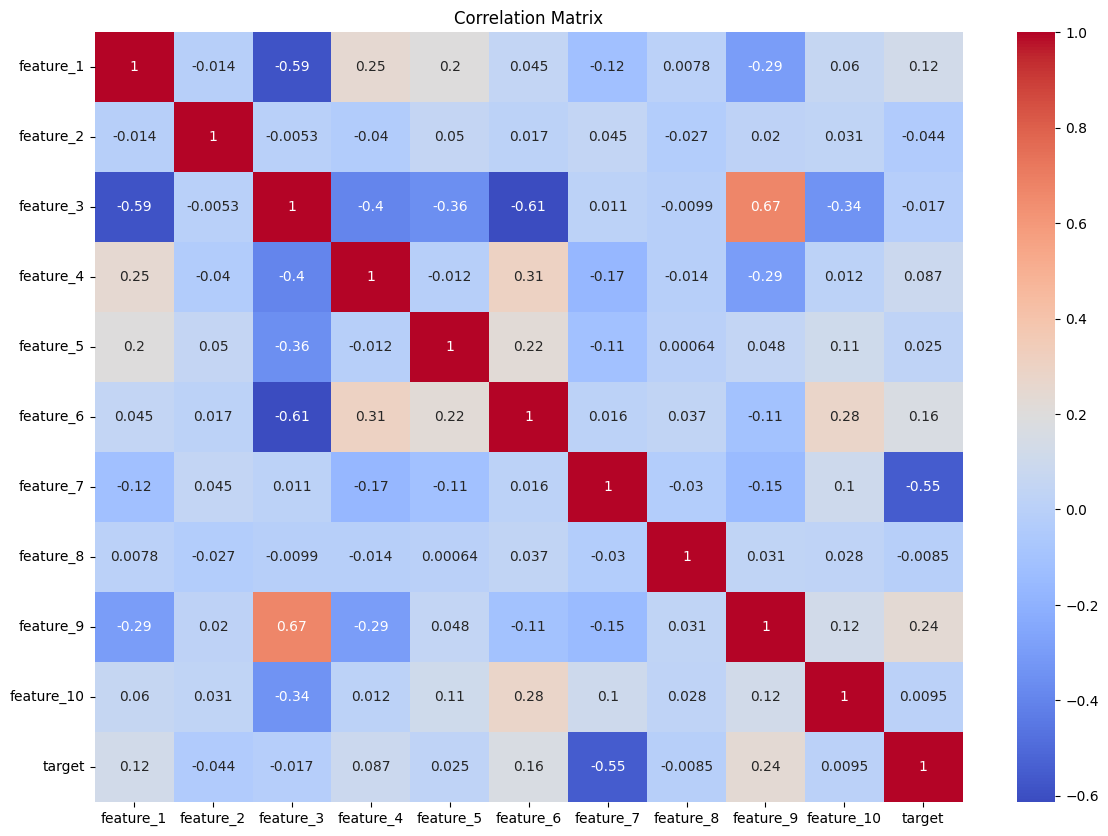

In [34]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [35]:
"""
OBSERVATIONS:

1. Some features are highly correlated.
2. Multicollinearity may affect linear models.
3. Feature selection can improve performance.
"""

'\nOBSERVATIONS:\n\n1. Some features are highly correlated.\n2. Multicollinearity may affect linear models.\n3. Feature selection can improve performance.\n'

In [37]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [38]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [39]:
df.drop_duplicates(inplace=True)

In [40]:
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [41]:
for col in num_cols:

    Q1 = df[col].quantile(0.25)

    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    df[col] = np.where(
        df[col] > upper,
        upper,
        df[col]
    )

    df[col] = np.where(
        df[col] < lower,
        lower,
        df[col]
    )

In [42]:
X = df.drop(target_col, axis=1)

y = df[target_col]

In [43]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [45]:
!pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable


You should consider upgrading via the 'C:\Program Files\Python310\python.exe -m pip install --upgrade pip' command.


In [46]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(
    X_train,
    y_train
)

In [47]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


You should consider upgrading via the 'C:\Program Files\Python310\python.exe -m pip install --upgrade pip' command.


In [48]:
from xgboost import XGBClassifier

In [49]:
print(XGBClassifier)

<class 'xgboost.sklearn.XGBClassifier'>


In [50]:
models = {

    "Logistic Regression": LogisticRegression(),

    "Decision Tree": DecisionTreeClassifier(),

    "Random Forest": RandomForestClassifier(),

    "KNN": KNeighborsClassifier(),

    "Naive Bayes": GaussianNB(),

    "SVM": SVC(probability=True),

    "XGBoost": XGBClassifier(
        objective='multi:softmax',
        eval_metric='mlogloss'
    ),

    "AdaBoost": AdaBoostClassifier(),

    "Gradient Boosting": GradientBoostingClassifier()
}


Training Logistic Regression
Accuracy: 0.81

Classification Report
              precision    recall  f1-score   support

         0.0       0.80      0.82      0.81        50
         1.0       1.00      0.88      0.94        50
         2.0       0.74      0.86      0.79        49
         3.0       0.73      0.69      0.71        51

    accuracy                           0.81       200
   macro avg       0.82      0.81      0.81       200
weighted avg       0.82      0.81      0.81       200



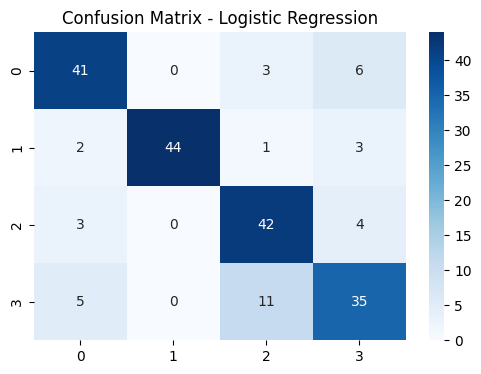


Training Decision Tree
Accuracy: 0.765

Classification Report
              precision    recall  f1-score   support

         0.0       0.78      0.72      0.75        50
         1.0       0.84      0.92      0.88        50
         2.0       0.71      0.82      0.76        49
         3.0       0.72      0.61      0.66        51

    accuracy                           0.77       200
   macro avg       0.76      0.77      0.76       200
weighted avg       0.76      0.77      0.76       200



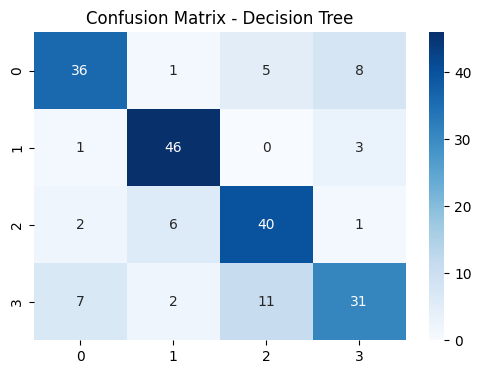


Training Random Forest
Accuracy: 0.875

Classification Report
              precision    recall  f1-score   support

         0.0       0.90      0.88      0.89        50
         1.0       0.98      0.88      0.93        50
         2.0       0.81      0.94      0.87        49
         3.0       0.84      0.80      0.82        51

    accuracy                           0.88       200
   macro avg       0.88      0.88      0.88       200
weighted avg       0.88      0.88      0.88       200



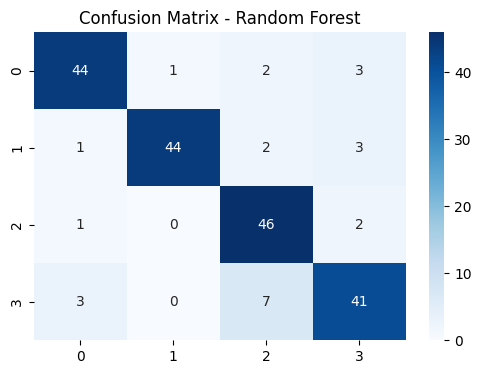


Training KNN
Accuracy: 0.865

Classification Report
              precision    recall  f1-score   support

         0.0       0.80      0.94      0.86        50
         1.0       1.00      0.86      0.92        50
         2.0       0.88      0.88      0.88        49
         3.0       0.82      0.78      0.80        51

    accuracy                           0.86       200
   macro avg       0.87      0.87      0.87       200
weighted avg       0.87      0.86      0.87       200



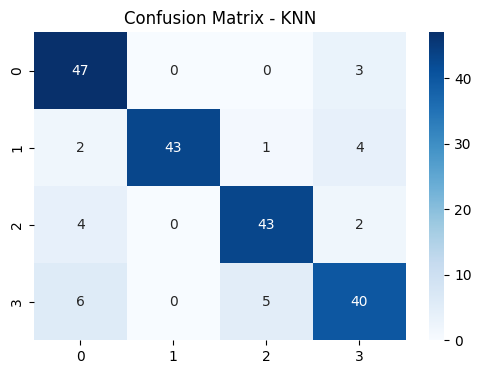


Training Naive Bayes
Accuracy: 0.785

Classification Report
              precision    recall  f1-score   support

         0.0       0.73      0.88      0.80        50
         1.0       0.95      0.82      0.88        50
         2.0       0.74      0.80      0.76        49
         3.0       0.75      0.65      0.69        51

    accuracy                           0.79       200
   macro avg       0.79      0.79      0.79       200
weighted avg       0.79      0.79      0.78       200



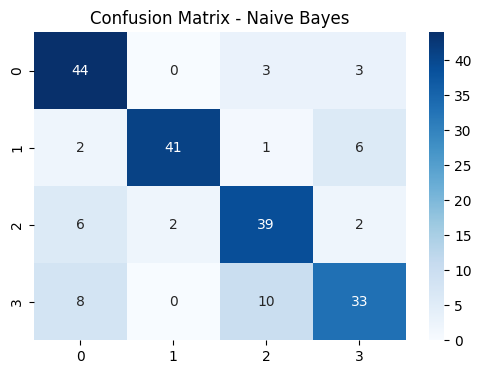


Training SVM
Accuracy: 0.895

Classification Report
              precision    recall  f1-score   support

         0.0       0.88      0.88      0.88        50
         1.0       1.00      0.92      0.96        50
         2.0       0.88      0.92      0.90        49
         3.0       0.83      0.86      0.85        51

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.90       200
weighted avg       0.90      0.90      0.90       200



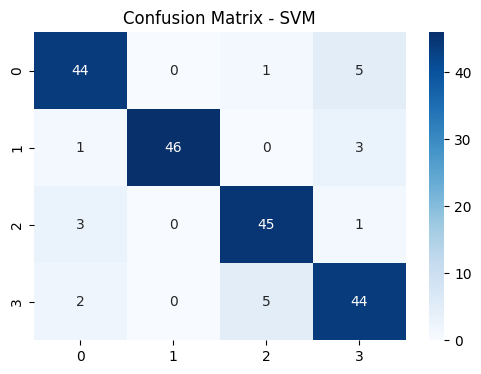


Training XGBoost
Accuracy: 0.895

Classification Report
              precision    recall  f1-score   support

         0.0       0.88      0.86      0.87        50
         1.0       0.96      0.92      0.94        50
         2.0       0.85      0.96      0.90        49
         3.0       0.90      0.84      0.87        51

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.89       200
weighted avg       0.90      0.90      0.89       200



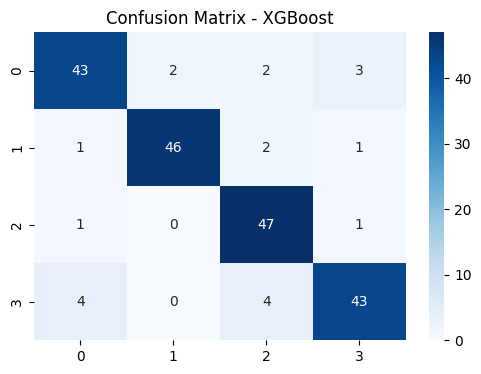


Training AdaBoost
Accuracy: 0.77

Classification Report
              precision    recall  f1-score   support

         0.0       0.80      0.66      0.73        50
         1.0       0.95      0.84      0.89        50
         2.0       0.66      0.92      0.77        49
         3.0       0.72      0.67      0.69        51

    accuracy                           0.77       200
   macro avg       0.79      0.77      0.77       200
weighted avg       0.79      0.77      0.77       200



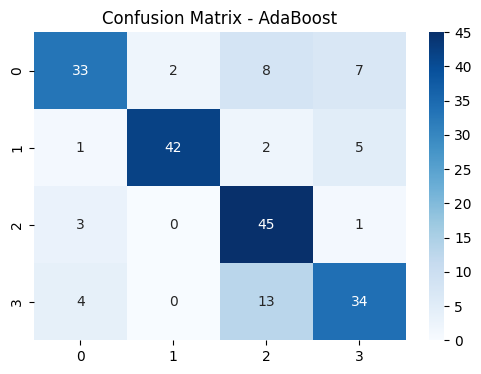


Training Gradient Boosting
Accuracy: 0.885

Classification Report
              precision    recall  f1-score   support

         0.0       0.88      0.92      0.90        50
         1.0       0.96      0.90      0.93        50
         2.0       0.82      0.96      0.89        49
         3.0       0.89      0.76      0.82        51

    accuracy                           0.89       200
   macro avg       0.89      0.89      0.88       200
weighted avg       0.89      0.89      0.88       200



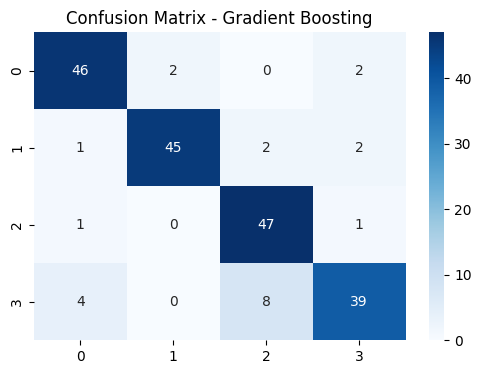

In [51]:
results = []

for name, model in models.items():

    print(f"\nTraining {name}")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average='weighted'
    )

    recall = recall_score(
        y_test,
        y_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted'
    )

    results.append([name, accuracy, precision, recall, f1])

    print("Accuracy:", accuracy)

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

Scaling

In [52]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.810,0.817444,0.810,0.811467
1,Decision Tree,0.765,0.763580,0.765,0.761406
2,Random Forest,0.875,0.880021,0.875,0.875543
3,KNN,0.865,0.872316,0.865,0.865779
4,Naive Bayes,0.785,0.793238,0.785,0.784941
5,SVM,0.895,0.897875,0.895,0.895853
6,XGBoost,0.895,0.896772,0.895,0.894823
7,AdaBoost,0.770,0.786456,0.770,0.770123
8,Gradient Boosting,0.885,0.888556,0.885,0.884082


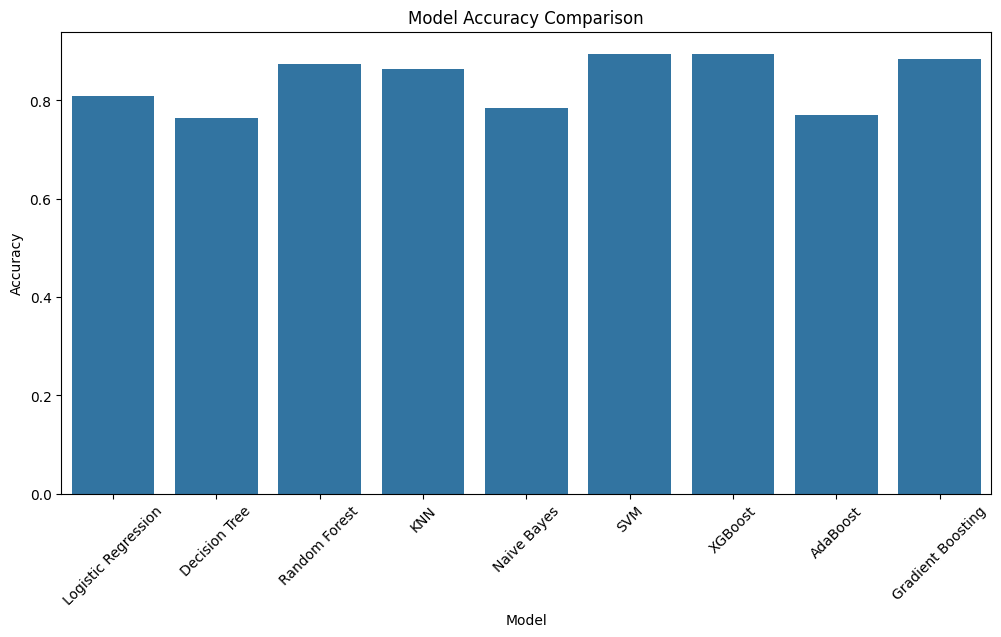

In [53]:
plt.figure(figsize=(12,6))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=results_df
)

plt.xticks(rotation=45)

plt.title("Model Accuracy Comparison")

plt.show()

Models

In [54]:
for name, model in models.items():

    scores = cross_val_score(
        model,
        X_scaled,
        y,
        cv=5,
        scoring='accuracy'
    )

    print(f"{name}: Mean Accuracy = {scores.mean()}")

Logistic Regression: Mean Accuracy = 0.8350000000000002
Decision Tree: Mean Accuracy = 0.768
Random Forest: Mean Accuracy = 0.882
KNN: Mean Accuracy = 0.8710000000000001
Naive Bayes: Mean Accuracy = 0.8049999999999999
SVM: Mean Accuracy = 0.9030000000000001
XGBoost: Mean Accuracy = 0.9030000000000001
AdaBoost: Mean Accuracy = 0.758
Gradient Boosting: Mean Accuracy = 0.882


Train & Evaluate


 Logistic Regression
              precision    recall  f1-score   support

         0.0       0.80      0.82      0.81        50
         1.0       1.00      0.88      0.94        50
         2.0       0.74      0.86      0.79        49
         3.0       0.73      0.69      0.71        51

    accuracy                           0.81       200
   macro avg       0.82      0.81      0.81       200
weighted avg       0.82      0.81      0.81       200



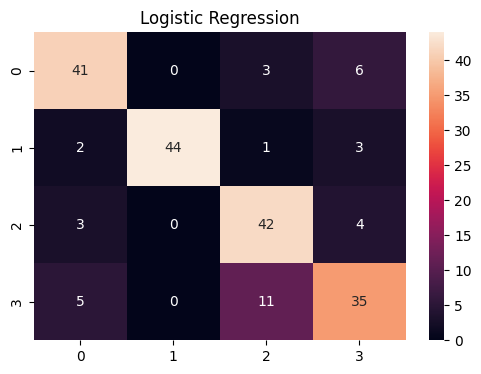


 Decision Tree
              precision    recall  f1-score   support

         0.0       0.76      0.76      0.76        50
         1.0       0.85      0.92      0.88        50
         2.0       0.69      0.78      0.73        49
         3.0       0.76      0.61      0.67        51

    accuracy                           0.77       200
   macro avg       0.76      0.77      0.76       200
weighted avg       0.77      0.77      0.76       200



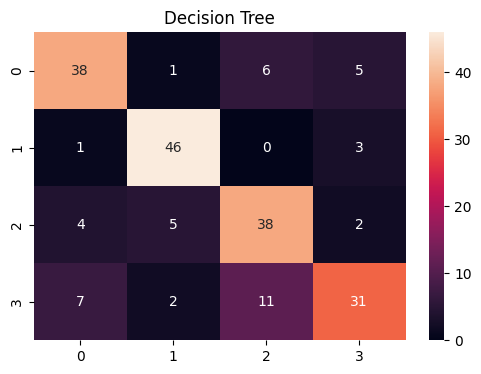


 Random Forest
              precision    recall  f1-score   support

         0.0       0.86      0.88      0.87        50
         1.0       0.98      0.88      0.93        50
         2.0       0.80      0.92      0.86        49
         3.0       0.83      0.78      0.81        51

    accuracy                           0.86       200
   macro avg       0.87      0.87      0.87       200
weighted avg       0.87      0.86      0.87       200



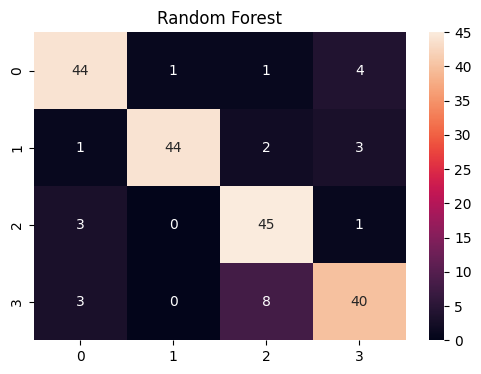


 KNN
              precision    recall  f1-score   support

         0.0       0.80      0.94      0.86        50
         1.0       1.00      0.86      0.92        50
         2.0       0.88      0.88      0.88        49
         3.0       0.82      0.78      0.80        51

    accuracy                           0.86       200
   macro avg       0.87      0.87      0.87       200
weighted avg       0.87      0.86      0.87       200



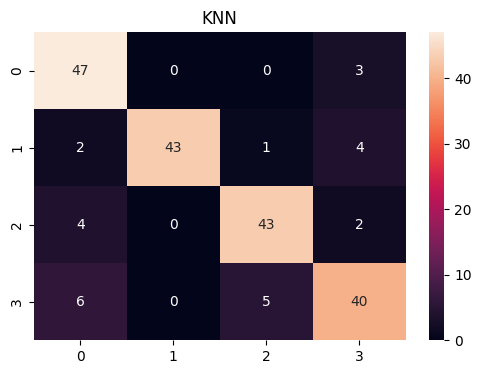


 Naive Bayes
              precision    recall  f1-score   support

         0.0       0.73      0.88      0.80        50
         1.0       0.95      0.82      0.88        50
         2.0       0.74      0.80      0.76        49
         3.0       0.75      0.65      0.69        51

    accuracy                           0.79       200
   macro avg       0.79      0.79      0.79       200
weighted avg       0.79      0.79      0.78       200



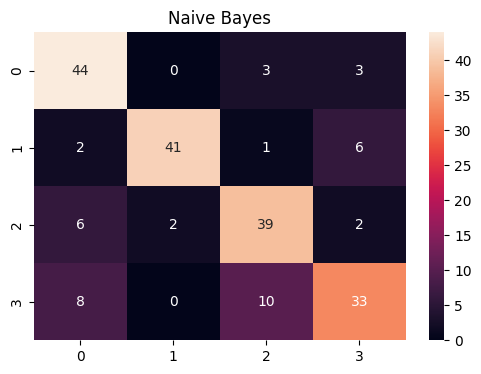


 SVM
              precision    recall  f1-score   support

         0.0       0.88      0.88      0.88        50
         1.0       1.00      0.92      0.96        50
         2.0       0.88      0.92      0.90        49
         3.0       0.83      0.86      0.85        51

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.90       200
weighted avg       0.90      0.90      0.90       200



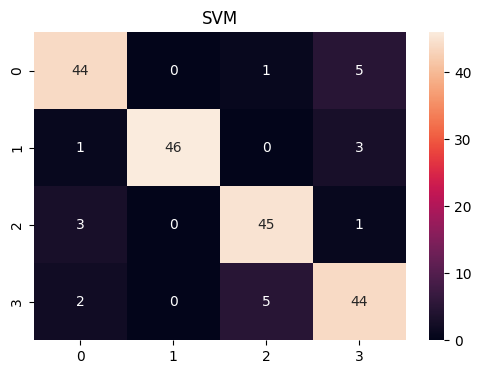


 XGBoost
              precision    recall  f1-score   support

         0.0       0.88      0.86      0.87        50
         1.0       0.96      0.92      0.94        50
         2.0       0.85      0.96      0.90        49
         3.0       0.90      0.84      0.87        51

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.89       200
weighted avg       0.90      0.90      0.89       200



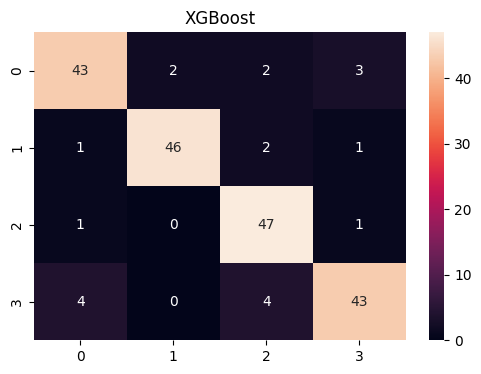


 AdaBoost
              precision    recall  f1-score   support

         0.0       0.80      0.66      0.73        50
         1.0       0.95      0.84      0.89        50
         2.0       0.66      0.92      0.77        49
         3.0       0.72      0.67      0.69        51

    accuracy                           0.77       200
   macro avg       0.79      0.77      0.77       200
weighted avg       0.79      0.77      0.77       200



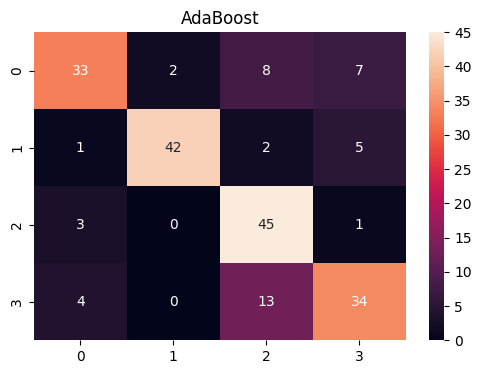


 Gradient Boosting
              precision    recall  f1-score   support

         0.0       0.88      0.90      0.89        50
         1.0       0.96      0.90      0.93        50
         2.0       0.82      0.96      0.89        49
         3.0       0.89      0.78      0.83        51

    accuracy                           0.89       200
   macro avg       0.89      0.89      0.88       200
weighted avg       0.89      0.89      0.88       200



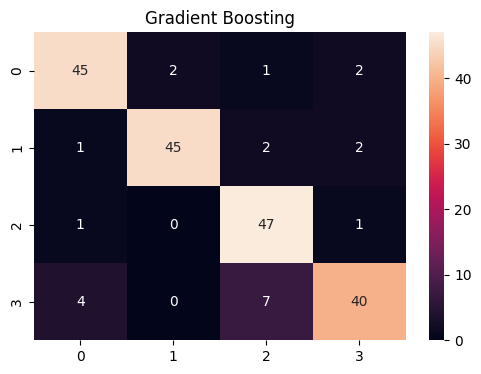

In [55]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    prec = precision_score(
        y_test,
        pred,
        average="weighted"
    )

    rec = recall_score(
        y_test,
        pred,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        pred,
        average="weighted"
    )

    results.append(
        [name, acc, prec, rec, f1]
    )

    print("\n", name)

    print(classification_report(
        y_test,
        pred
    ))

    cm = confusion_matrix(
        y_test,
        pred
    )

    plt.figure(figsize=(6,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d"
    )
    plt.title(name)
    plt.show()

Result Table

In [56]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

results_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1
5,SVM,0.895,0.897875,0.895,0.895853
6,XGBoost,0.895,0.896772,0.895,0.894823
8,Gradient Boosting,0.885,0.888634,0.885,0.884495
2,Random Forest,0.865,0.869506,0.865,0.865461
3,KNN,0.865,0.872316,0.865,0.865779
0,Logistic Regression,0.810,0.817444,0.810,0.811467
4,Naive Bayes,0.785,0.793238,0.785,0.784941
7,AdaBoost,0.770,0.786456,0.770,0.770123
1,Decision Tree,0.765,0.765041,0.765,0.762040


Accuracy Comparison

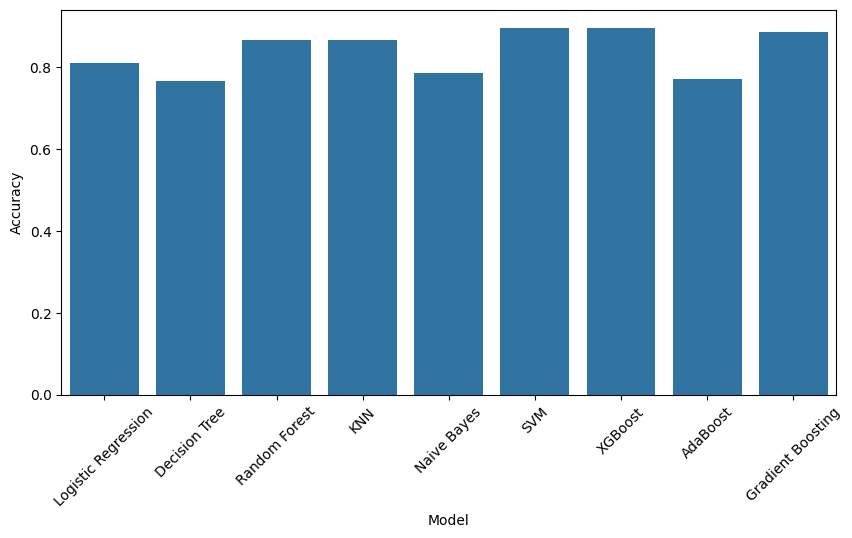

In [57]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=results_df
)

plt.xticks(rotation=45)

plt.show()

Cross Validation

In [58]:
rf = RandomForestClassifier()

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5
)

print(scores)

print(scores.mean())

[0.92  0.85  0.845 0.9   0.925]
0.8880000000000001


Hyperparameter Tuning

In [59]:
params = {

    "n_estimators":[100,200],

    "max_depth":[5,10,15],

    "min_samples_split":[2,5]
}

grid = GridSearchCV(

    RandomForestClassifier(),

    params,

    cv=5,

    scoring="accuracy"
)

grid.fit(X_train,y_train)

print(grid.best_params_)

best_model = grid.best_estimator_

{'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 100}


Final Evaluation

In [60]:
pred = best_model.predict(X_test)

print(
    accuracy_score(
        y_test,
        pred
    )
)

0.855


Save Model

In [ ]:
joblib.dump(
    best_model,
    "model.pkl"
)

joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']

In [62]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

joblib.dump(label_encoder, "encoder.pkl")

['encoder.pkl']

In [63]:
import joblib

joblib.dump(label_encoder, "encoder.pkl")

['encoder.pkl']

In [64]:
import os
print(os.listdir("../models"))

['model.pkl', 'scaler.pkl']
